In [1]:
conda activate omfitenv


Note: you may need to restart the kernel to use updated packages.


In [6]:
#%pip install --upgrade omfit_classes

In [7]:
#%pip install omas

In [3]:
from omfit_classes import omfit_eqdsk

In [4]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from uncertainties import ufloat
import numpy as np
from scipy.integrate import cumtrapz
from scipy.constants import mu_0
import os

In [36]:
#volume average
def vol_avg(fluxSurfaces, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        psi_geqdsk = fluxSurfaces['geo']['psin'] #using psin just because it's monotonically increasing, and psi is not
        prof_sized = np.interp(psi_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(fluxSurfaces, prof_sized)[-1]
        prof_sized_vol_avg = prof_sized_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(fluxSurfaces, 1)[-1]
        return prof_sized_vol_avg
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(fluxSurfaces, prof)[-1]
        prof_vol_avg = prof_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(fluxSurfaces, 1)[-1]
        return prof_vol_avg

#H factor definitions
def vol_integral(fluxSurfaces, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        psi_geqdsk = fluxSurfaces['geo']['psin'] #using psin just because it's monotonically increasing, and psi is not, but both are equispaced
        prof_sized = np.interp(psi_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(fluxSurfaces, prof_sized)[-1]
        return prof_sized_vol_int
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(fluxSurfaces, prof)[-1]
        return prof_vol_avg

def taue_h_mode(x,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58): #M = 2.5 for DT
    h_mode_vars = [x['ip'],x['bcentr'],x['density'],x['ptot_cps'],x['rsurf'],x['kappa'],x['eps']]
    return 0.0562*2.5**(0.19)*np.prod(np.power(h_mode_vars,np.array([a1,a2,a3,a4,a5,a6,a7])))

def taue_l_mode(x,a1=0.85,a2=1.2,a3=0.3,a4=0.5,a5=0.1,a6=0.2,a7=-0.5): #M = 2.5 for DT
    l_mode_vars = [x['ip'],x['rsurf'],x['aminor'],x['kappa'],x['density']/10,x['bcentr'],x['ptot_cps']] #this scaling law uses n20
    return 0.048*2.5**(0.5)*np.prod(np.power(x,np.array([a1,a2,a3,a4,a5,a6,a7])),axis=1)

def get_params_dict(gfile,ffile):
    ip = abs(ffile['ip'][-1])
    bt = abs(ffile['b0'][-1])
    
    rho_tor_norm = ffile['rho'][:]
    e_density_profile = ffile['ne'][-1] #10^19
    density_19_avg = vol_avg(gfile['fluxSurfaces'],e_density_profile,rho_tor_norm)
    
    Palpha = (ffile['pfuse'][-1] + ffile['pfusi'][-1]) #multiply by 5 would give fusion power, don't do for this
    Ptot = ffile['prfe'][-1] + ffile['prfi'][-1] + Palpha
    Rmaj = gfile['fluxSurfaces']['geo']['R'][-1]
    kappa = gfile['fluxSurfaces']['geo']['kap'][-1]
    aminor = gfile['fluxSurfaces']['geo']['a'][-1]
    eps = gfile['fluxSurfaces']['geo']['eps'][-1]
    params_dict = {'ip':ip,'bcentr':bt,'density':density_19_avg,'ptot_cps':Ptot,'rsurf':Rmaj,'kappa':kappa,'eps':eps,'aminor':aminor}
    return params_dict

def calc_H98y2(gfile,ffile):
    rho = ffile['rho'][:]
    ne_prof = ffile['ne'][-1,:] #10^19/m^3
    Te_prof = ffile['te'][-1,:] #keV
    ni_prof_tot = ffile['ni'][-1,:] + ffile['nz0'][-1,:] + ffile['nhe'][-1,:]
    Ti_prof = ffile['ti'][-1,:]
    total_pressure = (ne_prof*Te_prof+ni_prof_tot*Ti_prof)*1602.2  #to convert to Pa (multiplication is for from eV to Joules)
    
    Wthr = vol_integral(gfile['fluxSurfaces'],(3/2)*total_pressure,rho)/1e6 #MJ
    #print('Wthr =',Wthr)

    params_dict = get_params_dict(gfile,ffile)
    #print(params_dict)
    tau_H98y2 = taue_h_mode(params_dict,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58)
    #print('tau_H98y2 =',tau_H98y2)
    tau_E = Wthr/params_dict['ptot_cps']
    #print('tau_E =',tau_E)
    H98y2 = tau_E/tau_H98y2
    #print('H98y2 =',H98y2)

    return H98y2


 simulation_641737_0001
fGr = 0.8350575751425345
H98y2 = 0.9579569117172271
fail
1.426+/-0.018
1.2094725688140582

 simulation_641737_0002
fGr = 0.8179163853511151
H98y2 = 1.0748962023653337
fail
1.462+/-0.019
1.2305350297725093

 simulation_641737_0007
fGr = 0.8363546670381317
H98y2 = 1.0463328464622776
fail
1.454+/-0.019
1.2095517789093027

 simulation_641737_0003
fGr = 0.8166853010362922
H98y2 = 0.9744138951767363
fail
1.434+/-0.018
1.230468048268163

 simulation_641737_0006
fGr = 0.8008535375030065
H98y2 = 1.198751117721366
fail
1.495+/-0.021
1.2525465895950112

 simulation_641737_0004
fGr = 0.8192993546696438
H98y2 = 1.177762500678735
fail
1.488+/-0.021
1.2306108923090588

 simulation_641737_0008
fGr = 0.8377557995158513
H98y2 = 1.1551190341615043
fail
1.482+/-0.020
1.2096411334773511

 simulation_641737_0005
fGr = 0.7982392196068427
H98y2 = 0.9925138254590842
fail
1.443+/-0.018
1.2524260243071137

 simulation_641737_0000
fGr = 0.7993047037012945
H98y2 = 1.0848352903877136
fail
1

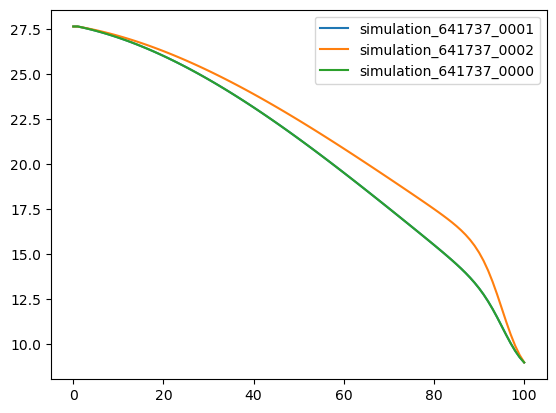

In [44]:
cwd = os.getcwd()
SCAN_dir = cwd+'/SCAN'
sims = [f for f in os.listdir(SCAN_dir) if f.startswith('simulation_') and not f.endswith('.conf') and not f.endswith('log')]

for sim in sims:
    print('\n',sim)
    ## First just find the fastran.nc and geqdsk file
    work_dir = SCAN_dir+'/'+sim+'/work'
    fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
    ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
    gfile = work_dir+'/'+fastran_dir[0]+'/g000001.00001'

    rootgrp = Dataset(ffile)
    geqdsk = omfit_eqdsk.OMFITeqdsk(gfile)

    ## Some ffile variables
    Rmaj = rootgrp['r0'][-1]
    Bt = float(rootgrp['b0'][-1])
    Ip = rootgrp['ip'][-1]
    aminor = rootgrp['a0'][-1]

    ## Calculate Greenwald fraction
    nebar = rootgrp['nebar'][-1]
    n_Gr = Ip/(np.pi*aminor**2)
    f_Gr = nebar/10/n_Gr #divide by 10 to switch from 10^19 to 10^20
    print('fGr =',f_Gr)

    ## Calculate H factor
    print('H98y2 =',calc_H98y2(geqdsk,rootgrp))
    
    ## Calculate Angioni peaking
    Gamma_NBI = 0
    
    #Grab profiles
    rho = rootgrp['rho'][:]
    if sim in ['simulation_641737_0000','simulation_641737_0001','simulation_641737_0002']:
        plt.plot(ne_prof,label=sim)
    ne_prof = rootgrp['ne'][-1,:] #10^19/m^3
    Te_prof = rootgrp['te'][-1,:] #keV
    ni_prof_tot = rootgrp['ni'][-1,:] + rootgrp['nz0'][-1,:] + rootgrp['nhe'][-1,:]
    Ti_prof = rootgrp['ti'][-1,:]
    p_prof = (ne_prof*Te_prof+ni_prof_tot*Ti_prof) #should be in keV*10**19/m**3 for Angioni beta equation  #*1602.2 to convert to Pa (multiplication is for from eV to Joules)
    
    ##compare pressures from g and f files
    #plt.plot(rho,p_prof*1602.2)
    #plt.plot(rho_geqdsk,pres_geqdsk)
    # pres_f_vol_avg = vol_avg(geqdsk['fluxSurfaces'],p_prof*1602.2,rho)
    # print(pres_g_vol_avg)
    # print(pres_f_vol_avg)
    
    #Calculate volume averages
    ne_lin_avg = nebar
    
    ne_vol_avg = vol_avg(geqdsk['fluxSurfaces'],ne_prof,rho)
    p_vol_avg = vol_avg(geqdsk['fluxSurfaces'],p_prof,rho)
    Te_vol_avg = vol_avg(geqdsk['fluxSurfaces'],Te_prof,rho)
    
    #Calculate regression variables
    nu_eff = 0.2*ne_vol_avg*Rmaj/(Te_vol_avg**2) #don't use line average for this density average
    beta = 4.02e-3*p_vol_avg/(Bt**2)
    
    n02 = ne_prof[int(0.2*len(ne_prof))]
    
    #Calculate Angioni peaking
    npeaking = ufloat(1.347,0.014) - ufloat(0.117,0.005)*np.log(nu_eff) + ufloat(1.331,0.117)*Gamma_NBI - ufloat(4.030,0.810)*beta
    
    n_peak_left = npeaking.nominal_value-npeaking.std_dev
    n_peak_right = npeaking.nominal_value+npeaking.std_dev
    if n02/ne_lin_avg >= n_peak_left and n02/ne_lin_avg <= n_peak_right:
        print('pass')
    else:
        print('fail')
    print(npeaking)
    print(n02/ne_lin_avg)

plt.legend()
plt.show()   
#print(rootgrp.variables)